<div style="color:blue">

**Programming for Data Science (UFCFVQ-15-M)**

**Assignment - Part 2**

This part of the assignment focuses on using
NumPy/SciPy, Pandas, and Matplotlib/Seaborn
to combine and analyse two datasets related to mental health.

## Overview

Part 2

  - Q2.1: explore data [20 marks]
  - Q2.2: detect and remove outliers [10 marks]
  - Q2.3: hypothesis test [10 marks]

For each of the questions Q2.1-Q2.3 there is a blank *Markdown* cell
for explanations, formulas, etc. and
a blank *code* cell for Python code.
You can add more cells.
Any explanations can be entered as Markdown or as comments with the code.
You do not have to use LaTeX (the markup language that can be used
to typeset formulas in Jupyter Notebook files).
You do have to make sure that any notation you use is clear.


## Marking Guideline
The marks for each question are indicated above.

There is not necessarily a relation between the number of marks for a question
and the amount of work required or the level of difficulty.
You may find some questions more difficult than others.

Try to answer as many questions as you can.


Q2.1

- 0: no answer, irrelevant or incorrect answer
- 1-4: insufficient and/or many mistakes
- 5-8: acceptable, but incomplete and/or substantial mistakes
- 9-12: good, substantial answer, with good explanation
- 13-16: very good, mostly complete, only minor mistake or issue with explanation
- 17-20: excellent, complete answer with clear and concise explanation

Q2.2-3

- 0: no answer, irrelevant or incorrect answer
- 1,2: insufficient and/or many mistakes
- 3,4: acceptable, but incomplete and/or substantial mistakes
- 5,6: good, substantial answer, with good explanation
- 7,8: very good, mostly complete, only minor mistake or issue with explanation
- 9,10: excellent, complete answer with clear and concise explanation

Note that the pass mark for postgraduate assessments is 50%.

<div style="color:blue">

# Part 2
To obtain good marks, you should make both your writing and your code clear, correct and concise.

</div>

In [113]:
# Put all the import statements for this notebook in this cell.
#handling the data
import pandas as pd
import numpy as np

#Visulizations
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

# will lead to static images of the plot embedded in the notebook
%matplotlib inline

# scientific computing
from scipy import stats

<div style="color:blue">

## Q2.1: Explore the Dataset to Identify an Interesting Pattern or Trend [20 marks]

Use appropriate visualisations (using, for example,  Matplotlib or Seaborn)
to illustrate your exploration.
You should include at least three visualisations as part of your exploration.
You could consider other ways to explore the data such as data summaries or
transformations.
You must include an explanation of the dataset exploration, your selected
interesting pattern or trend and your reasons for selecting it.
</div>

The dataset contains the statistics across different countries in terms  mental health disorder  from 1990 to 2017. 
The aim is to explore trends and patterns over the years, investigate relationships between disorders, compare the extremes.
python libraries  for data analysis and visualisation will be used including standard exploratory data analysis techniques.
All this will help guide subsequnt visualisation and interpretations.

In [114]:
# Load both datasets

mental_disorder = pd.read_csv("part2a.csv")
substance_disorder = pd.read_csv("part2b.csv")

In [115]:
#check shape of both dataset to know if they are of equal columns.
print(f"Shape of Part 2A: {mental_disorder.shape}")
print(f"Shape of Part 2B: {substance_disorder.shape}")


Shape of Part 2A: (6468, 7)
Shape of Part 2B: (6468, 4)


In [116]:
# combine both datasets on common columns
mental_health_joined = mental_disorder.merge(substance_disorder, on=["Entity", "Year"], how="left")

#view the combined dataset
mental_health_joined.head()

print(f"Shape after Merge: {mental_health_joined.shape}")

# Check for data loss
if mental_disorder.shape[0] < substance_disorder.shape[0]:
    print(f"Warning: {mental_disorder.shape[0] - substance_disorder.shape[0]} rows were dropped during merging.")
else:
    print("Data Merge successful: No rows lost.")


Shape after Merge: (6468, 9)
Data Merge successful: No rows lost.


In [117]:
#check data types and structure
print(" Dataset type and Structure:\n") 
print(mental_health_joined.info())

 Dataset type and Structure:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6468 entries, 0 to 6467
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Entity                     6468 non-null   object 
 1   Year                       6468 non-null   int64  
 2   Schizophrenia (%)          6468 non-null   float64
 3   Bipolar disorder (%)       6468 non-null   float64
 4   Eating disorders (%)       6468 non-null   float64
 5   Anxiety disorders (%)      6468 non-null   float64
 6   Depression (%)             6468 non-null   float64
 7   Drug use disorders (%)     6468 non-null   float64
 8   Alcohol use disorders (%)  6468 non-null   float64
dtypes: float64(7), int64(1), object(1)
memory usage: 454.9+ KB
None


In [118]:
#Descriptive sstatistics of the mental_health dataset
print("\n Descriptive Statistics:\n")
print (mental_health_joined.describe(include = "all"))



 Descriptive Statistics:

             Entity         Year  Schizophrenia (%)  Bipolar disorder (%)  \
count          6468  6468.000000        6468.000000           6468.000000   
unique          231          NaN                NaN                   NaN   
top     Afghanistan          NaN                NaN                   NaN   
freq             28          NaN                NaN                   NaN   
mean            NaN  2003.500000           0.211644              0.719145   
std             NaN     8.078372           0.044253              0.171589   
min             NaN  1990.000000           0.146902              0.314535   
25%             NaN  1996.750000           0.181530              0.615532   
50%             NaN  2003.500000           0.199563              0.693134   
75%             NaN  2010.250000           0.236365              0.835063   
max             NaN  2017.000000           0.375110              1.206597   

        Eating disorders (%)  Anxiety disorders 

In [119]:
#check for missing values (nulls) in the dataset
print("Null values in the dataset: \n")
print (mental_health_joined.isnull().sum())

Null values in the dataset: 

Entity                       0
Year                         0
Schizophrenia (%)            0
Bipolar disorder (%)         0
Eating disorders (%)         0
Anxiety disorders (%)        0
Depression (%)               0
Drug use disorders (%)       0
Alcohol use disorders (%)    0
dtype: int64


In [120]:
#check for dupliactes
mental_health_dupl = mental_health_joined[mental_health_joined.duplicated()]

print("There are", len(mental_health_dupl), "duplicated rows in the mental health dataset")


There are 0 duplicated rows in the mental health dataset


# Key insights from the dataset exploration

Two datsets were provided for analysis:

1. Mental health prevalence over the years (Schizophrenia, Bipolar disorder, Eating disorders, Anxiety disorders, Depression).

2. Substance related disorders(Alchol use disorder and drugs use disorders).

These datasets were merged based on Entity and Year to create a comprehensive dataset, assigned to the variable mental_health_joined.

- The combined dataset contains 6468 observations, where each row represent a combination of entity and its repective year and disorders.

- The combined dataset consist of one the following:
    - Categorical variable: Entity, 
    - Temporal variable: Year (1990-2017) which implies that the dataset is time series based, which is perfect for time based visualizations.
    - Nuumerical: Seven disorders prevalence which is expressed in percentages.

- All variables in the dataset are correctly assigned to their respective data types as in the original dataset.

- There are no duplicates and missing values present in the dataset hence imputation and cleaning is not required.

Descriptive Statistics:

- The descriptive statistics are split into unique (Entity) and numeric data (Year and mental health disorders).
  There are 231 unique entities in the dataset while the most frequent entity is afghanistan which appears 28 times (freq = 28). 

- Numerical Descriptive statitics:
- Anxiety disorders shows the highest average prevalence(approximately 4%), followed by Depression (apprximately 3.50 %) 

- Schizophrenia has the lowest average prevalence(approximately 0.21%), followed by Eating disorders (approximately 0.24%)

- Substance disorders show that Alcohol use disorders have a higher avearge prevalence (approximately 1.59%) than Drug use disorders (approximately 0.86%)

Combining the datasets allows the integration of mental health and substance disorders exploration across entities and year. This allows for a robust analysis of yearly trends and potential correlations between the two conditions.

EDA Next step:
The merged dataset will be used for:
1. Yearly trend analysis
2. Correlation analysis
3. Identify the Top five countries with overall mental health burden.

This will help find patterns and trends in the combined dataset.

## Yearly Trend analysis of all disorders
- Goal:
Show and Examine the pattern and changes of the prevalence of each disorder  over time across all the entities.

yearly trends of disorders over the years

   Year  Schizophrenia (%)  Bipolar disorder (%)  Eating disorders (%)  \
0  1990           0.209548              0.715392              0.221774   
1  1991           0.209586              0.715740              0.222076   
2  1992           0.209634              0.716091              0.222481   
3  1993           0.209690              0.716430              0.223033   
4  1994           0.209751              0.716755              0.223710   

   Anxiety disorders (%)  Depression (%)  Drug use disorders (%)  \
0               3.957269        3.506288                0.808283   
1               3.960009        3.510948                0.813466   
2               3.962778        3.515033                0.818692   
3               3.965405        3.518531                0.823780   
4               3.967976        3.521437                0.828389   

   Alcohol use disorders (%)  
0                   1.546533  
1                   1.553500  
2         

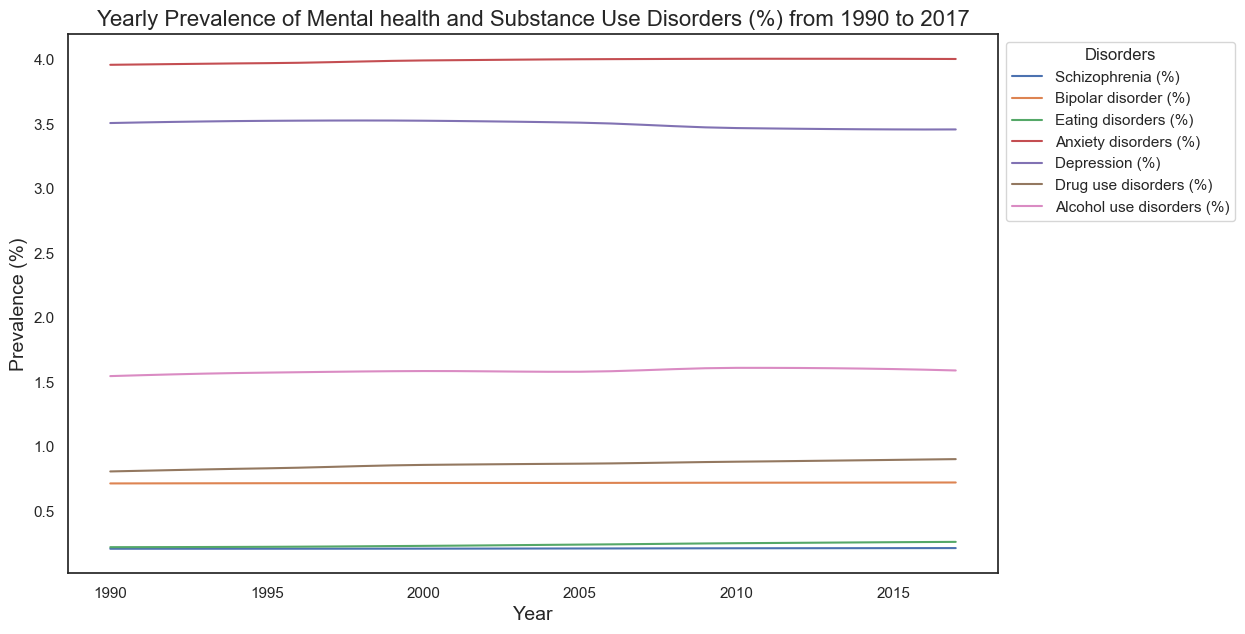

In [121]:
# set the overall plot style for readability
sns.set(style="white")


# create a list and assign all the disorder columns to a variable
disorders = ["Schizophrenia (%)", "Bipolar disorder (%)", 
             "Eating disorders (%)", "Anxiety disorders (%)", "Depression (%)", "Drug use disorders (%)" , "Alcohol use disorders (%)"]

#group by year and compute the yearly average prevalance and reset the index for easy plotting.
yearly_trend_averages = mental_health_joined.groupby("Year")[disorders].mean().reset_index()

#Tabular view of the yearly trends.

print("yearly trends of disorders over the years\n")

 #print first five for readability
print(yearly_trend_averages.head())

#plot the yearly trends of all disorders
#set the size of the plot
plt.figure(figsize=(12,7))

# plot each disorder using a for loop as used in class
for disorder in disorders:
    plt.plot(yearly_trend_averages["Year"], yearly_trend_averages[disorder],  label=disorder)


#add titles and labelings
plt.title("Yearly Prevalence of Mental health and Substance Use Disorders (%) from 1990 to 2017", fontsize=16)
plt.xlabel("Year", fontsize=14)
plt.ylabel("Prevalence (%)", fontsize=14)

# add legend for clarity
plt.legend(title="Disorders", loc="upper left", bbox_to_anchor=(1, 1))

# show the plot
plt.show()


## Key insight and Trends

A line chart was used for the above figure as it works in line with time series analysis to show trends overime.

The figure above shows the following:

- Anxiety disorders consistently have the highest prevalence incleasing a little bit from 4.0% in 1990 to about 4.1 around 2001, follwed by depression with a little decline in the early to mid 2000s, showing some stability around 3.4-3.5% overtime.

- Alcohol use disorder shows moderate prevalence, where Alchol use disorder shows some stability around 1.6% and drug use disorder shows a slight increase from 0.8% in 1990 to closely 0.9% in 2017. Bipolar disorder remained stable about 0.7% over the years.

- Eating disorders and Schizoprenia have the lowest prevalence. There was a slight increase in eating disorder but both eating disorder and schizoprenia remained below 0.3%. 

## Correlation Analysis
Goal:
- show if there is a correlation between mental health disorders and substance use disorder or just among the mental health disorder.


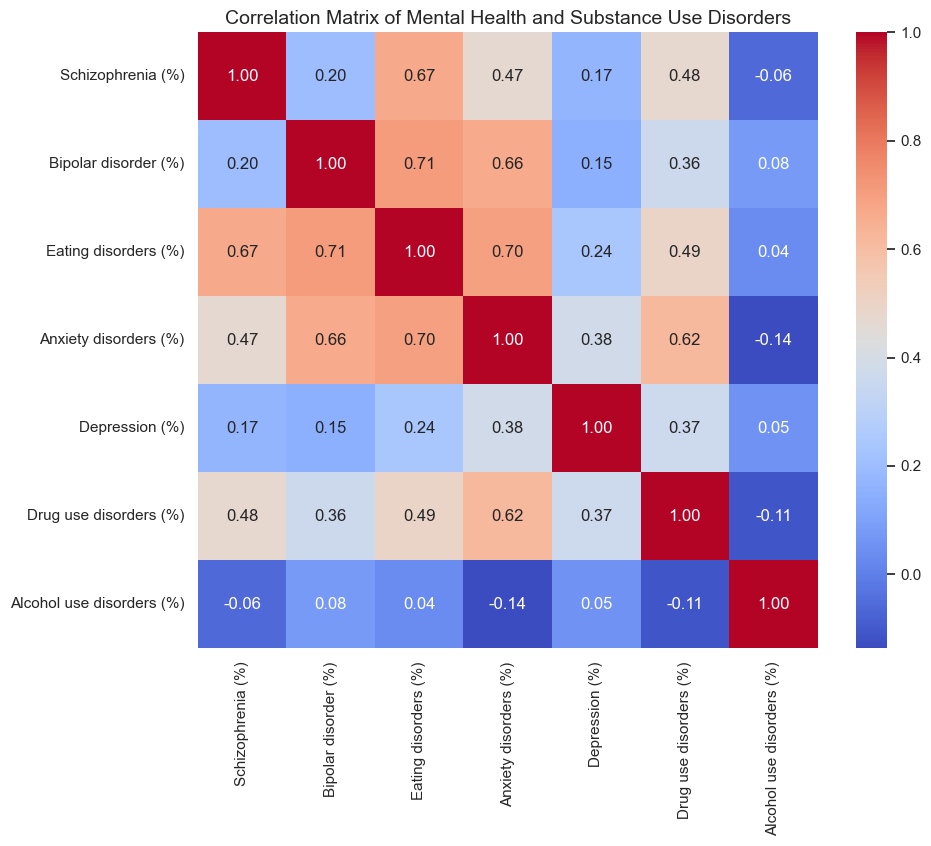

In [122]:
## set the overall plot style for readability
sns.set(style="white")

#calculate correlation matrix
corr_matrix = mental_health_joined[disorders].corr()

#set the size of the plot
plt.figure(figsize=(10,8))

# plot heatmap
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")

# add titles
plt.title("Correlation Matrix of Mental Health and Substance Use Disorders", fontsize=14)

plt.show()## Key Insights

## Key Insights

The heatmap uses a correlation matrix as an exploratory tool to understand how different mental and substance use disordes are related and how they move together.

The result show that stronger relationships exist mainly among mental health disorders, while substance use disorders display weaker and nearly zero correlations with most mental health conditions.

for example:
- Eating disorders show strong correlation with bipolar disorder (r = 0.71), anxiety disorders (r = 0.70), and schizophrenia (r = 0.67). 
- Anxiety disorders shows moderate to strong correlation with bipolar disorder (r = 0.66) and drug use disorders (r = 0.62). These values suggest that these conditions often move together across countries (Entities).
-In contrast, depression shows weaker correlations with most disorders, including schizophrenia (r = 0.17) and bipolar disorder (r = 0.15), indicating a more independent pattern. 
- Alcohol use disorders have nearly zero or negative correlations with schizophrenia (r = −0.06), anxiety disorders (r = −0.14), and drug use disorders (r = −0.11).

This early observation helps guide later analysis by indicating which relationships may be meaningful to investigate further.


## Identify top five countries with the highest overall mental

Goal: 
- find the top five countries with mental health burden
- group each countries according to the percentage of the disorders.

while getting the statistics of the top countries, the disorders contributing to the prevalence of the top countries will be visualised for better understanding.

In [123]:
#compute the average prevalence for each country across all years and reset the index for easy plotting.
country_averages = mental_health_joined.groupby("Entity")[disorders].mean().reset_index()

#select top five countries with the highest overall mental health burden
country_averages["overall burden"] = country_averages[disorders].sum(axis=1)

#select top five countries
top_5countries = country_averages.sort_values(by= "overall burden", ascending=False).head(5)

#Display he result
print("Top five countries with the highest overall mental health burden:\n")
print(top_5countries)

Top five countries with the highest overall mental health burden:

            Entity  Schizophrenia (%)  Bipolar disorder (%)  \
80       Greenland           0.318408              0.592052   
143    New Zealand           0.340113              1.199014   
217  United States           0.338117              0.653710   
10     Australasia           0.360540              1.153425   
148  North America           0.335768              0.659933   

     Eating disorders (%)  Anxiety disorders (%)  Depression (%)  \
80               0.500551               5.669651        6.459109   
143              0.643235               8.651309        4.086397   
217              0.513658               6.741584        4.744655   
10               0.806650               6.895850        4.679497   
148              0.508377               6.590146        4.674825   

     Drug use disorders (%)  Alcohol use disorders (%)  overall burden  
80                 1.814019                   3.433462       18.787251  

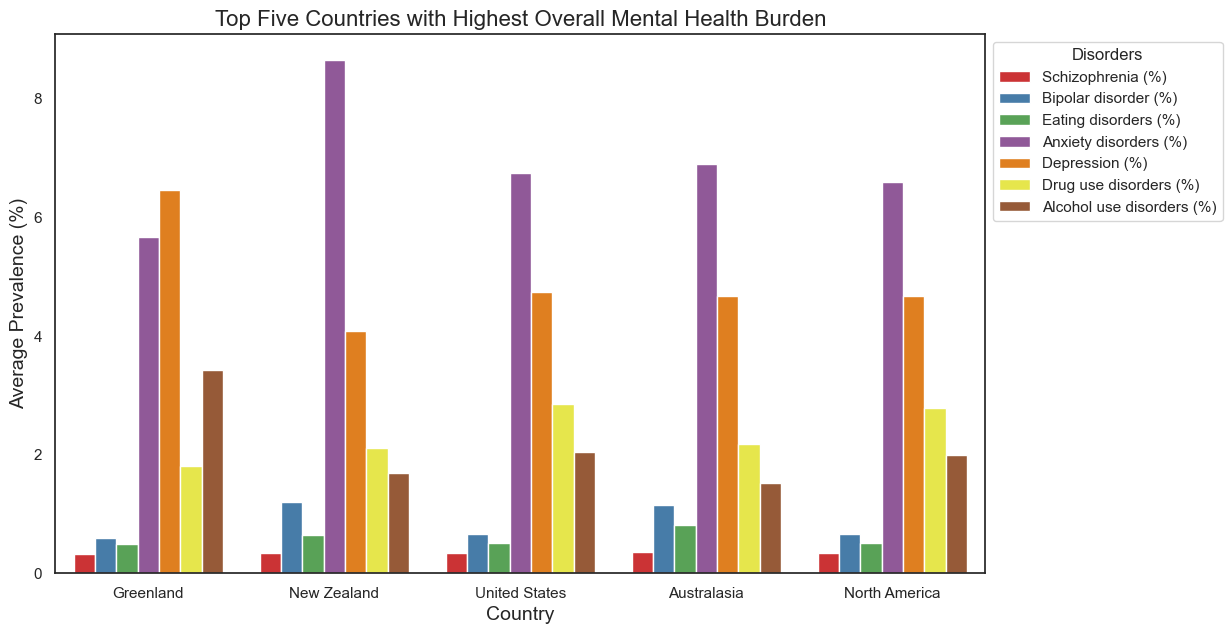

In [124]:
# turn the disorders columns into bar rows.
top_5countries_plot = top_5countries.melt(id_vars=["Entity", "overall burden"],
                                         value_vars=disorders,
                                         var_name="Disorder",
                                         value_name="Prevalence (%)")

#Set the figure size for better readability
plt.figure(figsize=(12,7))
sns.barplot(data=top_5countries_plot,
            x="Entity",          #countries on x-axis
            y="Prevalence (%)", #percentage prevalence on y-axis
            hue="Disorder", #different colors for different disorders
            orient="v", #makes it vertical
            palette="Set1" #color palette
              
)

#add titles and labelings
plt.title("Top Five Countries with Highest Overall Mental Health Burden", fontsize=16)
plt.xlabel("Country", fontsize=14)
plt.ylabel("Average Prevalence (%)", fontsize=14)

# add legend for clarity
plt.legend(title="Disorders", loc="upper left", bbox_to_anchor=(1, 1))

# show the plot
plt.show()

## Key Insights

The grouped bar plot above reveals the following:

- The top five countries with highest mental health disorders.
- In all the identified top five entities(countries), Anxiety disorders and depression represent the highest prevalence, while schizoprenia and eating disorder shows the lowest prevalence.

- Greenland shows a higher prevalence for depression(approximately 6.5%) compared to other entities, while New Zealand shows the highest peak of anxiety disorder (approximately 8.6%). 


<div style="color:red">

**Feedback**

??
</div>

<div style="color:red">

**Mark**

??/20
</div>

<div style="color:blue">

## Q2.2: Detect and Remove Any Outliers in the Data Used for Your Interesting Pattern [10 marks]

Use an appropriate technique to detect and remove any outliers in the data
used for your interesting pattern or trend.
You must include an explanation of the detection method used, how it works,
and any outliers detected.
NOTE: there may not be any detectable outliers using the selected detection
method –
if this is the case, please state this clearly in the explanation given.
</div>




## Interesting Patterns: Examining the Anxiety and Depression Relationship

Among all mental health conditions in the dataset, anxiety disorders (mean = 3.99%, SD = 1.17%) and depression (mean = 3.50%, SD = 0.66%) emerged as highly prevalent conditions with considerable variation across countries.

Anxiety prevalence ranged from 2.02% to 8.97%, while depression ranged from 2.14% to 6.60%. The observed moderate positive correlation (r = 0.34) between these conditions suggested a potential relationship. 

To further vexamine this relationship and ensure findings were not driven by extreme values, outlier detection was conducted on both variables using boxplots and the IQR method.

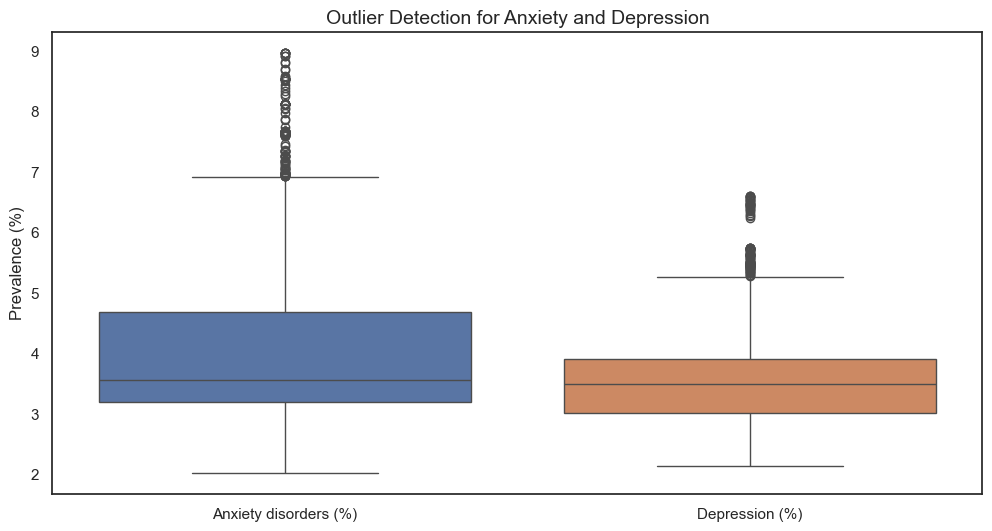

In [107]:
# Set the figure size
plt.figure(figsize=(12,6))

# Create a boxplot to visualise the distribution and outliers for Anxiety disorders and Depression
sns.boxplot(
    data=mental_health_joined[["Anxiety disorders (%)", "Depression (%)"]]
)

plt.title("Outlier Detection for Anxiety and Depression", fontsize=14)
plt.ylabel("Prevalence (%)")

plt.show()

In [108]:
disorders_pattern = ["Anxiety disorders (%)", "Depression (%)"]
# create a dictionary to store outliers
outliers_summary = {}

for disorder in disorders_pattern:
    Q1 = mental_health_joined[disorder].quantile(0.25)
    Q3 = mental_health_joined[disorder].quantile(0.75)
    
    # calculate the interquartile range (IQR)
    IQR = Q3 - Q1

    # define the lower and upper bounds for outliers
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    #identify the outliers
    outliers = mental_health_joined[(mental_health_joined[disorder] < lower_bound) |(mental_health_joined[disorder] > upper_bound)][["Entity", "Year", disorder]]

    outliers_summary[disorder] = outliers

    print(f"\n{disorder}")
    print(f"Lower bound: {lower_bound:.3f}, Upper bound: {upper_bound:.3f}")
    print(f"Number of outliers detected: {len(outliers)}")




Anxiety disorders (%)
Lower bound: 0.949, Upper bound: 6.922
Number of outliers detected: 123

Depression (%)
Lower bound: 1.645, Upper bound: 5.273
Number of outliers detected: 99


## Key Insights

Outliers were identified in anxiety disorder and depression, individual points as seen above the upper whiskers:

- The interquartile range(IQR) was used because of it's wide academic use and  it's robustness for skewed distribution and it doesnt assume Normality.

- for each disorder, it identifies the outliers at any point that falls below the lower bound (Q1 - (1.5 x IQR)) or above the upper bound (Q3 + (1.5 x IQR)).

- The visual representation was taken by using a boxplot then further did a numerical computation to support the boxplot allowing to view the upper and lower bounds, and exact number of the outlier present in each disorder.

## Removing the outliers

Outliers were identified using the Interquartile range (IQR) method.
But how will this be handled:

- Although the identified outliers represent valid country level observations rather than data errors, they lie far from the median of the data and can disproportionately influence statistical measures.
- From the descriptive statistics in Q2.1:

    Anxiety disorders (%)
    Median = approximately 3.55
    max = approximately 8.97
    The maximum number is more than twice the median.

    Depression (%)
    Median = approximately 3.50
    max = approximately 6.60
    The maximum number is amlost double the median.



In [109]:
# Create a copy of the dataset to ensure that outlier removal does not affect the original data
mh_filtered = mental_health_joined.copy()

for disorder in disorders_pattern:
    Q1 = mh_filtered[disorder].quantile(0.25)
    Q3 = mh_filtered[disorder].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    mh_filtered = mh_filtered[
        (mh_filtered[disorder] >= lower_bound) &
        (mh_filtered[disorder] <= upper_bound)
    ]

print("Original dataset:", mental_health_joined.shape)
print("Filtered dataset:", mh_filtered.shape)

Original dataset: (6468, 9)
Filtered dataset: (6243, 9)


- Using the IQR method, a total of 222 outliers were detected in the two disorders. which is about 3.4% of the data.

- Its a relatively small proportion therefore should be mild changes in further analysis.

- After removing all rows identified as outliers, the dataset was reduced from 6,468 to 6,243 observations. 
 

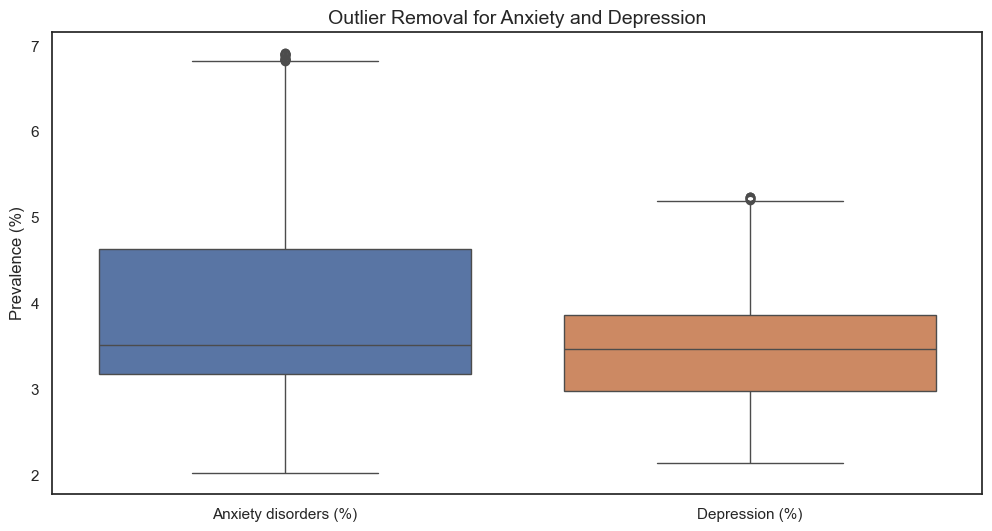

In [110]:
#draw a boxplot to visualize the effect of the outlier removal.

# Set the figure size
plt.figure(figsize=(12,6))

# Create a boxplot to visualise the distribution and outliers for Anxiety disorders and Depression
sns.boxplot(
    data=mh_filtered[["Anxiety disorders (%)", "Depression (%)"]]
)
#add overalll title for the figure
plt.title("Outlier Removal for Anxiety and Depression", fontsize=14)
plt.ylabel("Prevalence (%)")

plt.show()    

Boxplots were used to compare the data before and after outlier removal using the IQR method.

- Before filtering, disorders showed extreme values far from the median of the data. After filtering, the spread of the distribution was reduced, meaning that the extreme values has been reduced which makes trend easier to visualize 
- The outlier removal was done without altering the main data structure.


<div style="color:red">

**Feedback**

??
</div>

<div style="color:red">

**Mark**

??/10
</div>

<div style="color:blue">

## Q2.3: Hypothesis Test [10 marks]

Define a hypothesis using an appropriate hypothesis testing formulation.
Provide an explanation for your choice.
Using an appropriate Python library, test this hypothesis.
You must include a detailed explanation of your findings to achieve good marks for this task.
</div>

outliers were identified and removed using the interquartile range (IQR) method, and subsequent analysis will be  conducted on the filtered dataset to improve robustness.

The relationship between anxiety disorders and depression will then be visualised using a pair plot to see the relationship and movement.

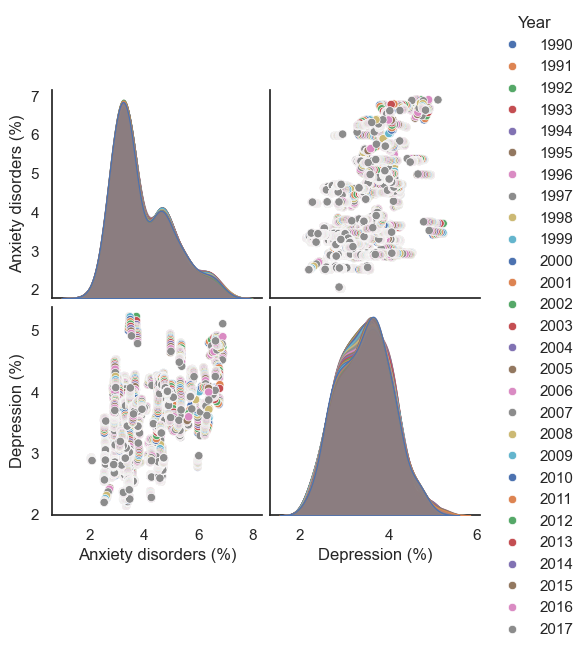

In [111]:
#
# Code can go here.

sns.pairplot(mh_filtered, 
             vars=["Anxiety disorders (%)", "Depression (%)"], 
             hue="Year", palette="deep");

The pair plot above illustrates the relationship between anxiety disorders and depression across countries and years.

- A positive trend movement is observed, this indicating that higher anxiety prevalence is generally associated with higher depression prevalence.

- The spread of the points suggests a moderate to weak relationship rather than a strong  linear relationship with noticeable  clusters around moderate levels of anxiety and depression, with few countries at low and high extreme.

Initial exploratory in Q2.1 analysis used a Pearson correlation heatmap to identify relationship among disorders. 

- This revealed a moderate  positive relationship between anxiety disorders and depression. 

- However, visual inspection of the data after outlier removal showed that  a bell shaped (normal) distribution was not guaranteed, given the bimodal distribution of Anxiety disorder.

- Although, Depression appears to be slightly unimodal with a peak, a normal distribution cannot be said about the two disorders simultenously.

- Therefore, Spearman’s rank correlation test will be used for hypothesis testing, as it does not assume normality and is more robust to non linear relationships making it less sensitive to the shape of the data.


## Stating the Null and Alternative Hypothesis


<div align="center"><font size=2.5><b><i>H</i><sub>0</sub>: there is no statistical significant relationship between Anxiety disorders and Depression across the entities.</b></font></div>






<div align="center"><font size=2.5><b><i>H</i><sub>a</sub>: there is some statiscal significant relationship between Anxiety disorders and Depression across the entities.</b></font></div>


The p-value will be used to make the decision whether to reject the the null hypothesis or fail to reject the null hypothesis.

In [112]:
def compute_spearmanr_stats(df, columns):
    x = "Anxiety disorders (%)"
    
    df_corr = pd.DataFrame()  # Correlation matrix
    df_p = pd.DataFrame()     # P-value matrix
    
    for y in columns:
        r, p = stats.spearmanr(df[x], df[y])
        #correlation coefficient
        df_corr.loc[x, y] = r
        #get p-value
        df_p.loc[x, y] = p
        
    return df_corr, df_p


df_corr, df_p = compute_spearmanr_stats(
    mh_filtered,
    ["Depression (%)"]
)

print("Correlation coefficients:\n", df_corr)
print("\nP-values:\n", df_p)

Correlation coefficients:
                        Depression (%)
Anxiety disorders (%)        0.306758

P-values:
                        Depression (%)
Anxiety disorders (%)   3.847432e-136


### Result and conclusion

- The Spearman’s rank correlation also revealed a statistically significant moderate positive relationship between anxiety disorder and depression (ρ = 0.307 (approximately), p < 0.005).

- Although the moderate correlation suggest that anxiety and depression are related, but the relationship is not strong enough which means there could be other mental health factors that may influence depression.

- The reduction in coefficient from previous pattern in q2.1 reflects that the extreme values and non linear patterns may have inflated the initial Pearson estimate.

- Therefore, the null hypothesis is rejected, indicating a statistically significant relationship between anxiety disorders and depression across countries.


<div style="color:red">

**Feedback**

??
</div>

<div style="color:red">

**Mark**

??/10
</div>